# Compliant wedge demonstration

This notebook compares compliant-wedge Green’s functions with homogeneous Green’s functions for the same GeoSlip2D interface geometry. It forward models uniform backslip above a specified locking depth, then generates synthetic data with the compliant-wedge model and inverts those data with both homogeneous and wedge Green’s functions.

The compliant wedge model contains three elastic zones with homogeneous properties. A (compliant) accretionary wedge with shear modulus $\mu_w$, contintental crust with shear modulus $\mu_c$, and subducting slab with shear modulus $\mu_s$

![Interface Geometry](./images/wedge_interface.png)

## Imports

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import geoslip2d as gs2d

# import helper functions for the notebook.
from geoslip2d.notebook_helpers import (
    make_synthetic_observations,
    patch_center_depths,
    patch_center_x,
    plot_inversion_results,
    plot_surface_velocities,
    run_pair_inversions,
    surface_velocity,
    uniform_backslip_above_depth,
)

cwd = Path.cwd().resolve()
if (cwd / "src" / "geoslip2d").is_dir():
    PROJECT_ROOT = cwd
else:
    PROJECT_ROOT = cwd.parent

OUTPUT_DIR = PROJECT_ROOT / "examples" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"OUTPUT_DIR   = {OUTPUT_DIR}")

PROJECT_ROOT = /Users/kajjohns/Library/CloudStorage/OneDrive-IndianaUniversity/FromGoogle/files/Release/GeoSlip2D
OUTPUT_DIR   = /Users/kajjohns/Library/CloudStorage/OneDrive-IndianaUniversity/FromGoogle/files/Release/GeoSlip2D/examples/outputs


## 1. Shared interface geometry and observation grid

Both Green's-function constructions in this notebook use this same GeoSlip2D `InterfaceGeometry` and the same `xobs` grid.

InterfaceGeometry(n_patch=49, x=[0, 240] km, z=[-0, 45.8] km)


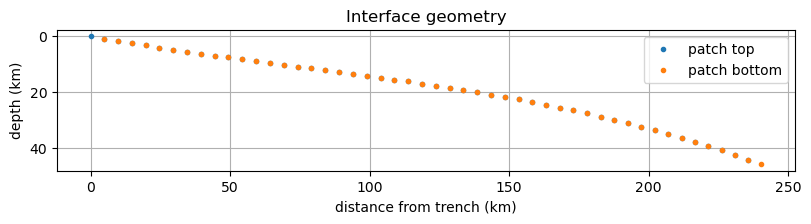

In [2]:
# Shared interface and observation grid.
faultdip_trench = 10.0
faultdip_bottom = 20.0
x_trench = 0.0
x_bottom = 238.0
z_bottom = 45.0
patch_length = 5.0

xobs = np.linspace(15, 500.0, 300)
locking_depth_km = 25.0
backslip_rate = 1.0

interface = gs2d.make_interface_geometry_legacy(
    faultdip_trench=faultdip_trench,
    x_trench=x_trench,
    x_bottom=x_bottom,
    faultdip_bottom=faultdip_bottom,
    z_bottom=z_bottom,
    patch_length=patch_length,
)
print(interface.summary())
fig = gs2d.plot_interface(interface)
plt.show()

## 2. Build homogeneous and compliant_wedge Green's functions

completed 1 of 49 patches
completed 2 of 49 patches
completed 3 of 49 patches
completed 4 of 49 patches
completed 5 of 49 patches
completed 6 of 49 patches
completed 7 of 49 patches
completed 8 of 49 patches
completed 9 of 49 patches
completed 10 of 49 patches
completed 11 of 49 patches
completed 12 of 49 patches
completed 13 of 49 patches
completed 14 of 49 patches
completed 15 of 49 patches
completed 16 of 49 patches
completed 17 of 49 patches
completed 18 of 49 patches
completed 19 of 49 patches
completed 20 of 49 patches
completed 21 of 49 patches
completed 22 of 49 patches
completed 23 of 49 patches
completed 24 of 49 patches
completed 25 of 49 patches
completed 26 of 49 patches
completed 27 of 49 patches
completed 28 of 49 patches
completed 29 of 49 patches
completed 30 of 49 patches
completed 31 of 49 patches
completed 32 of 49 patches
completed 33 of 49 patches
completed 34 of 49 patches
completed 35 of 49 patches
completed 36 of 49 patches
completed 37 of 49 patches
completed 

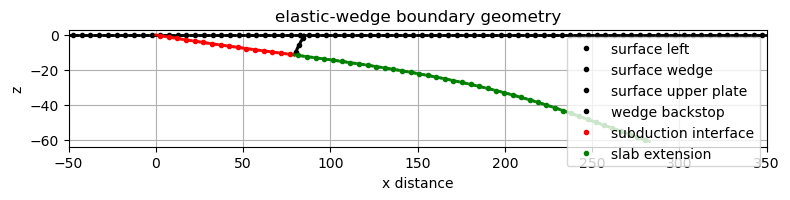

In [3]:
# Homogeneous reference.
greens_hom = gs2d.build_greens(
    "homogeneous",
    interface,
    xobs,
    length_override=patch_length,
    progress=True,
)

# Compliant-wedge backend. sync_geometry_from_interface=True copies the shared
# interface parameters into the native wedge solver configuration.
wedge_cfg = gs2d.WedgeConfig(
    wedge_bot=12.0,
    wedge_top_x=90.0,
    L_slab=50.0,
    W=200.0,
    mu1=1.0,
    mu2=0.1,   # compliant wedge
    mu3=10.0,
    nu=0.25,
    sync_geometry_from_interface=True,
    progress=True,
    verbose=True,
)

gs2d.plot_wedge_geometry(config=wedge_cfg, interface=interface, xlim=(-50, 350))

greens_nonhom = gs2d.build_greens(
    "wedge",
    interface,
    xobs,
    wedge_cfg,
)

## 3. Forward model uniform backslip above the locking depth

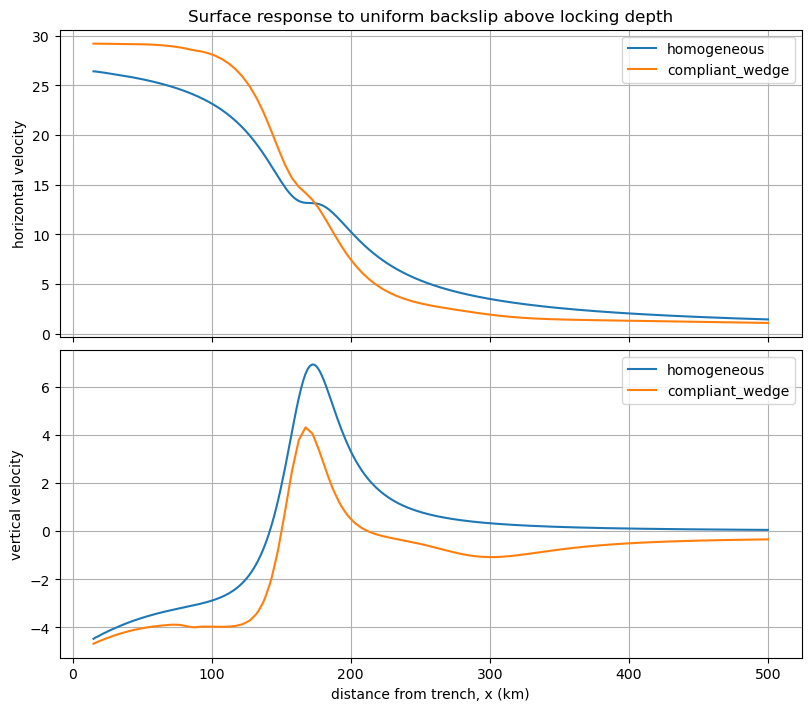

In [5]:
slip_hom = uniform_backslip_above_depth(greens_hom, locking_depth_km, backslip_rate=30)
slip_nonhom = uniform_backslip_above_depth(greens_nonhom, locking_depth_km, backslip_rate=30)

vel_hom = surface_velocity(greens_hom, slip_hom)
vel_nonhom = surface_velocity(greens_nonhom, slip_nonhom)

fig = plot_surface_velocities(xobs, vel_hom, vel_nonhom, "compliant_wedge")
plt.show()

## 4. Synthetic inversion

The synthetic data are generated with the **compliant_wedge** Green's functions using the same uniform-backslip model. The same synthetic horizontal and vertical velocities are then inverted twice: once with homogeneous Green's functions and once with compliant_wedge Green's functions.

Homogeneous inversion WRMS:     1.949
Non-homogeneous inversion WRMS: 0.925


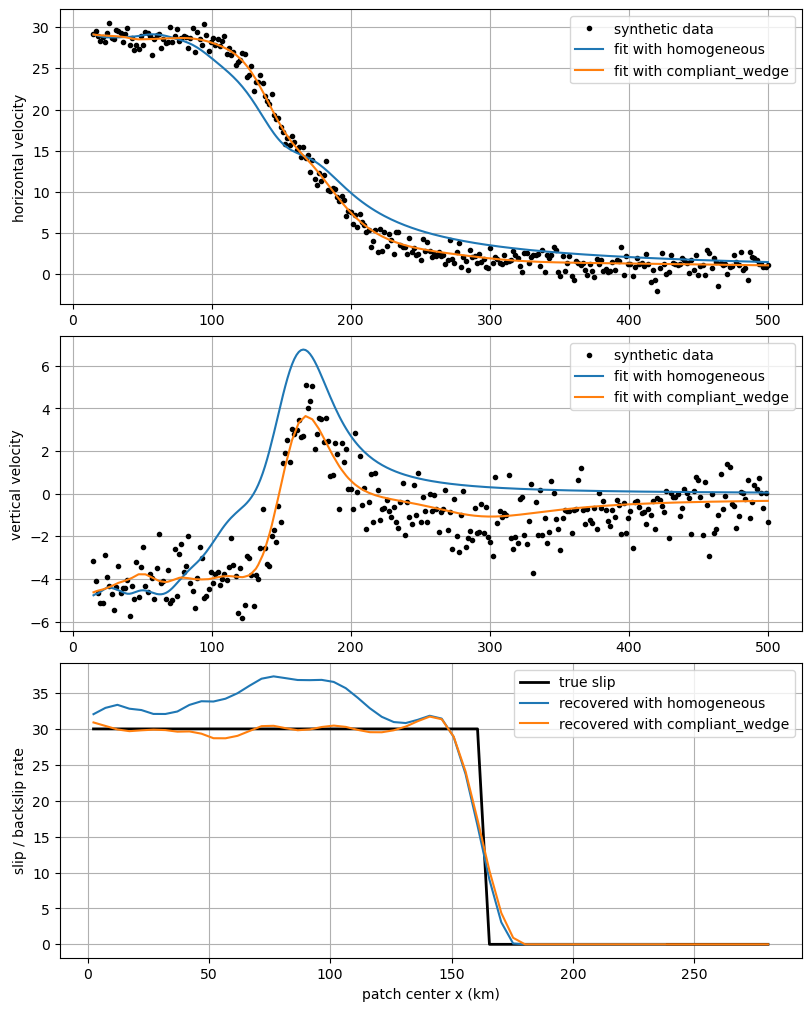

In [6]:
truth_slip = slip_nonhom.copy()
observations = make_synthetic_observations(
    greens_nonhom,
    truth_slip,
    sigma_h=1,
    sigma_v=1,
    noise=True,
)

out_hom, out_nonhom = run_pair_inversions(
    observations,
    greens_hom,
    greens_nonhom,
    alpha=0.5,
)

fig = plot_inversion_results(
    greens_hom,
    greens_nonhom,
    truth_slip,
    out_hom,
    out_nonhom,
    "compliant_wedge",
)
plt.show()